# Análisis Exploratorio de los Datos EDA

Para realizar un Análisis Exploratorio de Datos (EDA), es fundamental comprender tanto la estructura como las características principales del conjunto de datos. Este proceso permite identificar patrones, detectar posibles valores atípicos, evaluar la calidad de los datos y entender la distribución de las variables, lo que facilita la posterior toma de decisiones. Durante el EDA, se pueden aplicar diversas técnicas visuales y estadísticas que proporcionan una visión más clara sobre las relaciones entre las variables, la presencia de posibles problemas de calidad de los datos (como valores faltantes o duplicados) y la normalidad de las distribuciones. En este contexto, el análisis permitirá determinar los aspectos más relevantes a tratar en las siguientes fases del proyecto, como la limpieza de datos, la selección de características y la construcción de modelos predictivos.

- **Inspección de la estructura de los datos**
- **Manejo de valores faltantes**
- **Identificación de valores atípicos**
- **Distribución de variables**
- **Correlación entre variables**
- **Análisis de variables categóricas**


## NYC Data

## Códigos y salidas del EDA

Para realizar un Análisis Exploratorio de Datos (EDA) de manera efectiva, es necesario importar librerías clave que faciliten la manipulación, visualización y análisis de los datos. Entre las más comunes se encuentran pandas para la manipulación de datos, numpy para operaciones matemáticas, matplotlib y seaborn para la creación de gráficos visuales, y scipy para análisis estadísticos. Estas librerías proporcionan las herramientas necesarias para explorar y entender las características principales del conjunto de datos.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import geopandas as gpd
import folium



### Carga y visualización de los datos

**Contenido**
***Descripción de las variables***

- **VendorID:** Identificador del proveedor que suministra el registro.
    1 = Tecnologías móviles creativas, LLC
    2 = VeriFone Inc.
- **tpep_pickup_datetime:** La fecha y hora en que se activó el medidor
- **tpep_dropoff_datetime:** La fecha y hora en que se apagó el medidor.
- **Passenger_count:** El número de pasajeros en el vehículo, según lo ingresado por el conductor.
- **Trip_distance:** La distancia del viaje en millas, según lo registrado por el taxímetro.
- **PULocationID:** Zona de Taxis TLC donde se activó el taxímetro.
- **DOLocationID:** Zona de Taxis TLC donde el taxímetro fue desactivado.
*- *RateCodeID:** El código de tarifa aplicable al final del viaje.
    1 = Tarifa estándar
    2 = JFK
    3 = Newark
    4 = Nassau o Westchester
    5 = Tarifa negociada
    6 = Viaje en grupo
- **Store_and_fwd_flag:** Indica si el registro del viaje se almacenó en la memoria del vehículo antes de la transmisión al proveedor debido a la falta de conexión al servidor.
    Y = Viaje de almacenamiento y reenvío
    N = No es un viaje de almacenamiento y reenvío
- **Payment_type:** Cómo el pasajero pagó el viaje, representado por un código numérico.
    1 = Tarjeta de crédito
    2 = Efectivo
    3 = Sin cargo
    4 = Disputa
    5 = Desconocido
    6 = Viaje anulado
- **Fare_amount:** La tarifa calculada por el taxímetro en función del tiempo y la distancia.
- **Extra:** Cargos adicionales, que actualmente incluyen solo los cargos por hora pico y noche de $0,50 y $1.
- **MTA_tax**: Se agregará automáticamente un impuesto de $0,50 según la tarifa medida.
- **Improvement_surcharge**: A $0.30 surcharge added at the start of the trip, implemented since 2015.
- **Tip_amount**: Propina con tarjeta de crédito. (Nota: Las propinas en efectivo no se registran aquí).
- **Tolls_amount:** Total de peajes pagados durante el viaje.
- **Total_amount:** El cargo total a los pasajeros, excluidas las propinas en efectivo.


```{note}
para la lectura de los datos en formato *´.parquet´* se instala una extensión de la libreria pandas, tal como se muestra a continuación*´pip install pandas fastparquet´* 
```

In [24]:
df_taxi = pd.read_parquet(r'C:\Users\PC\Desktop\ML_clase\jbook_ml20251\data\yellow_tripdata_2019-01.parquet')
df_taxi.shape

(7696617, 19)

In [25]:
df_taxi.head(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.00,0.3,9.95,NaN,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.00,0.3,16.30,NaN,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.00,0.3,5.80,NaN,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.00,0.3,7.55,NaN,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
5,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,5.76,0.3,13.31,NaN,NaN
6,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.00,0.3,55.55,NaN,NaN
7,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,6.5,0.5,0.5,1.25,0.00,0.3,9.05,NaN,NaN
8,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,13.5,0.5,0.5,3.70,0.00,0.3,18.50,NaN,NaN
9,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,10.0,0.5,0.5,1.70,0.00,0.3,13.00,NaN,NaN


### Preprocesamiento

El código proporcionado realiza un proceso de transformación y limpieza de datos en un conjunto de datos de viajes de taxi. Primero, selecciona un subconjunto relevante de columnas, como las fechas de recogida y entrega, la cantidad de pasajeros, la distancia recorrida, y los montos relacionados con el viaje. Luego, renombra algunas columnas para mejorar la claridad y convierte las fechas de recogida y entrega al formato adecuado. Posteriormente, extrae varias características temporales, como el año, mes, día, hora y el día de la semana del viaje, lo que facilita un análisis detallado según el tiempo. Además, calcula la duración de cada viaje restando la fecha de recogida de la de entrega y ajusta el monto total de cada viaje para asegurarse de que sea un valor absoluto, eliminando posibles valores negativos. Finalmente, elimina las columnas originales de las fechas de recogida y entrega, ya que ya no son necesarias. El resultado es un conjunto de datos limpio y estructurado, adecuado para un análisis más profundo.



In [26]:
def process_taxi_data(df_taxi):
    taxi = df_taxi[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
                   'DOLocationID','passenger_count', 'trip_distance','fare_amount','total_amount', 'payment_type', 'tolls_amount']].copy()
    # Renaming Columns
    new_names = {'tpep_pickup_datetime': 'PickUpDate', 'tpep_dropoff_datetime':'DropOffDate', 'passenger_count': 'Passengers', 
                 'trip_distance':'Distance'}
    taxi = taxi.rename(columns=new_names)
    # Correct Format in Date Columns
    taxi['PickUpDate'] = pd.to_datetime(taxi['PickUpDate'], format='%Y-%m-%d %H:%M:%S')
    taxi['DropOffDate'] = pd.to_datetime(taxi['DropOffDate'], format='%Y-%m-%d %H:%M:%S')
    # Create Columns for Date Analysis
    taxi['PickUpYear'] = taxi['PickUpDate'].dt.year
    taxi['PickUpMonth'] = taxi['PickUpDate'].dt.month
    taxi['PickUpWeek'] = taxi['PickUpDate'].dt.isocalendar().week
    taxi['PickUpDay'] = taxi['PickUpDate'].dt.day
    taxi['PickUpHour'] = taxi['PickUpDate'].dt.hour
    taxi['PickUpDayWeek'] = taxi['PickUpDate'].dt.dayofweek + 1 
    # Duration Column
    taxi['Duration'] = taxi['DropOffDate'] - taxi['PickUpDate']
    # Total Amount Column
    taxi['total_amount'] = taxi['total_amount'].abs()
    # Drop Date Columns
    taxi = taxi.drop(labels=['PickUpDate', 'DropOffDate'], axis=1)
    return taxi
taxi_df = process_taxi_data(df_taxi)

taxi_df = process_taxi_data(df_taxi)
taxi_df = taxi_df[['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth', 'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek','payment_type', 'tolls_amount', 'Duration' ]]
taxi_df.head(10)



,PULocationID,DOLocationID,Passengers,Distance,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration
0,151,239,1.0,1.5,7.0,9.95,2019,1,1,1,0,2,1,0.00,0 days 00:06:40
1,239,246,1.0,2.6,14.0,16.30,2019,1,1,1,0,2,1,0.00,0 days 00:19:12
2,236,236,3.0,0.0,4.5,5.80,2018,12,51,21,13,5,1,0.00,0 days 00:04:10
3,193,193,5.0,0.0,3.5,7.55,2018,11,48,28,15,3,2,0.00,0 days 00:03:20
4,193,193,5.0,0.0,52.0,55.55,2018,11,48,28,15,3,2,0.00,0 days 00:01:36
5,193,193,5.0,0.0,3.5,13.31,2018,11,48,28,16,3,2,5.76,0 days 00:02:37
6,193,193,5.0,0.0,52.0,55.55,2018,11,48,28,16,3,2,0.00,0 days 00:04:06
7,163,229,1.0,1.3,6.5,9.05,2019,1,1,1,0,2,1,0.00,0 days 00:07:09
8,229,7,1.0,3.7,13.5,18.50,2019,1,1,1,0,2,1,0.00,0 days 00:13:38
9,141,234,2.0,2.1,10.0,13.00,2019,1,1,1,0,2,1,0.00,0 days 00:12:00


In [27]:
taxi_df['Duration'].describe()

count                      7696617
mean     0 days 00:16:33.064894225
std      0 days 01:21:40.523766730
min             -59 days +11:19:30
25%                0 days 00:06:06
50%                0 days 00:10:11
75%                0 days 00:16:39
max               30 days 07:28:01
Name: Duration, dtype: object

El hallazgo de duraciones negativas en el conjunto de datos de los viajes de taxi indica que existen registros en los que la fecha de entrega (DropOffDate) es anterior a la fecha de recogida (PickUpDate). Este tipo de inconsistencias sugiere que puede haber errores en el registro de los datos, ya sea por un fallo en la captura de las fechas o problemas con el sistema de registro. Las duraciones negativas no son lógicas en el contexto de los viajes de taxi, ya que un viaje no puede tener un tiempo negativo entre el inicio y el final. Este tipo de datos erróneos podría ser el resultado de entradas incorrectas o de registros incompletos, como valores nulos o faltantes en alguna de las fechas. Es fundamental abordar estos errores durante el proceso de limpieza de datos, eliminando o corrigiendo estos registros para asegurar que los análisis posteriores sean válidos y reflejen la realidad de los viajes.


In [ ]:
taxi_df = taxi_df[(taxi_df['Duration'] >= pd.Timedelta(0)) & (taxi_df['Duration'] <= pd.Timedelta(days=1))]
taxi_df['Duration'].describe()

count                      7696608
mean     0 days 00:16:33.042845757
std      0 days 01:11:30.594548880
min                0 days 00:00:00
25%                0 days 00:06:06
50%                0 days 00:10:11
75%                0 days 00:16:39
max                0 days 23:59:59
Name: Duration, dtype: object

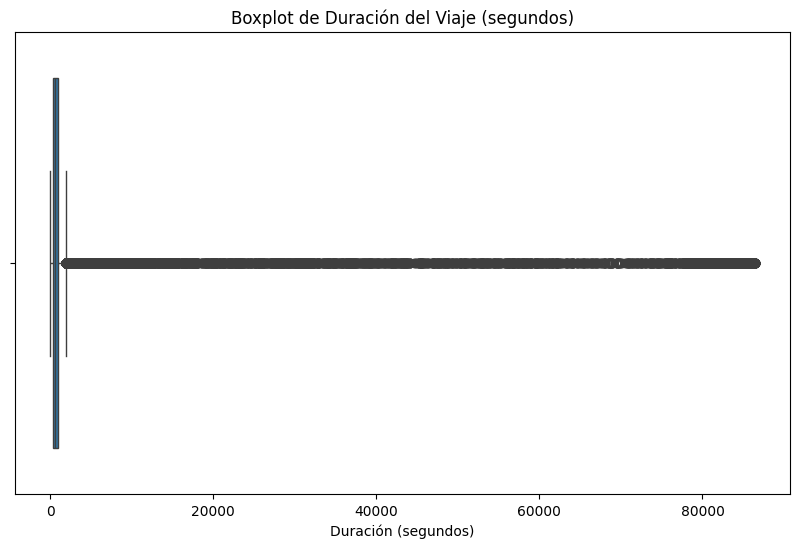

In [32]:
# Convertir la columna 'Duration' a números (segundos) para poder hacer un boxplot
taxi_df['Duration_seconds'] = taxi_df['Duration'].dt.total_seconds()

# Ahora puedes hacer un boxplot de 'Duration_seconds'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['Duration_seconds'])
plt.title('Boxplot de Duración del Viaje (segundos)')
plt.xlabel('Duración (segundos)')
plt.show()

In [12]:
# Convertir la columna 'Duration' a minutos
taxi_df['Duration_minutes'] = taxi_df['Duration'].dt.total_seconds() / 60

# Crear rangos de minutos
bins = [0, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, float('inf')]
labels = ['0-11', '11-21', '21-31', '31-41', '41-51', '51-61', '61-71', '71-81', '81-91', '91-101', '101+']

# Agrupar por rangos de minutos y contar las carreras
taxi_df['Duration_range'] = pd.cut(taxi_df['Duration_minutes'], bins=bins, labels=labels, include_lowest=True)
race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()

race_count_by_range

C:\Users\PC\AppData\Local\Temp\ipykernel_19660\3245737099.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()


Duration_range
0-11      4171029
11-21     2299490
21-31      748375
31-41      260636
41-51      100123
51-61       40545
61-71       16582
71-81        6262
81-91        2153
91-101        790
101+        21803
Name: Duration, dtype: int64

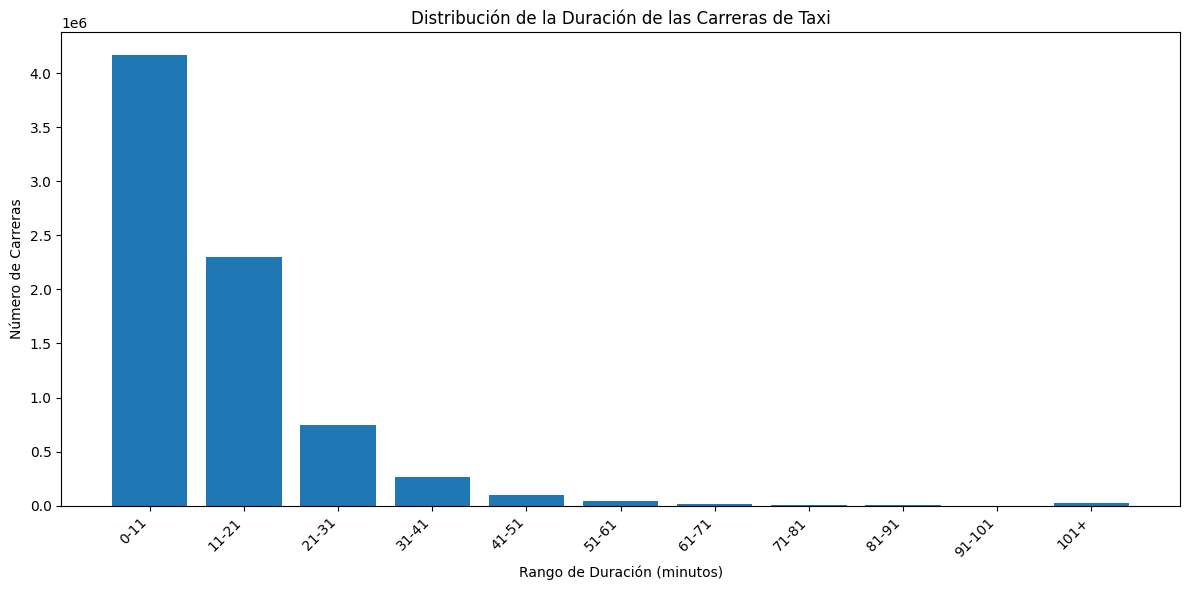

In [13]:
# Crear el gráfico de barras
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
plt.bar(race_count_by_range.index, race_count_by_range.values)

# Etiquetas y título del gráfico
plt.xlabel('Rango de Duración (minutos)')
plt.ylabel('Número de Carreras')
plt.title('Distribución de la Duración de las Carreras de Taxi')

# Rotar las etiquetas del eje x para una mejor legibilidad (opcional)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [14]:
# Check for NaN values in the DataFrame
nan_counts = taxi_df.isna().sum()

# Print the counts of NaN values for each column
print(nan_counts)

# Optionally, you can also check if there are any NaN values in the entire DataFrame
has_nan = taxi_df.isnull().values.any()
print(f"\nDoes the DataFrame contain NaN values? {has_nan}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
Duration_minutes    0
Duration_range      0
dtype: int64

Does the DataFrame contain NaN values? False


In [15]:

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

Número de filas duplicadas: 967


In [21]:
# Eliminar filas con valores NaN
taxi_df = taxi_df.dropna()

# Eliminar filas duplicadas
taxi_df = taxi_df.drop_duplicates()

# Verificar si se eliminaron los valores NaN y las filas duplicadas
nan_counts = taxi_df.isna().sum()
print(nan_counts)

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
DurationSeconds     0
DurationMinutes     0
Duration_minutes    0
Duration_range      0
dtype: int64
Número de filas duplicadas: 0


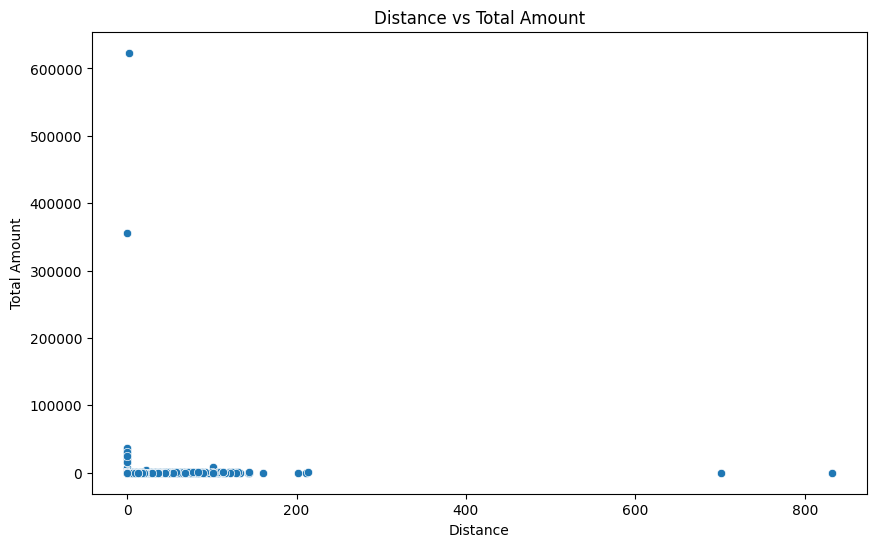

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='total_amount', data=taxi_df)
plt.title('Distance vs Total Amount')
plt.xlabel('Distance')
plt.ylabel('Total Amount')
plt.show()


In [19]:
zonas_df = pd.read_csv(r"C:\Users\PC\Desktop\ML_clase\jbook_ml20251\data\taxi+_zone_lookup.csv")
# Unir el DataFrame de taxis con las zonas usando PULocationID
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='PULocationID', right_on='LocationID', how='left')

# Unir también el DOLocationID para obtener la zona de destino
df_taxi = df_taxi.merge(zonas_df[['LocationID', 'Zone']], left_on='DOLocationID', right_on='LocationID', how='left', suffixes=('_pickup', '_dropoff'))

In [22]:
# Coordenadas de algunas zonas de recogida y entrega (ejemplo)
pickup_zones_coords = {
    'Manhattan Valley': [40.8071, -73.9610],
    'Upper West Side South': [40.7850, -73.9750],
    'Upper East Side North': [40.7847, -73.9523],
    'Queensbridge/Ravenswood': [40.7612, -73.9442],
    'Midtown North': [40.7549, -73.9808],
    'Sutton Place/Turtle Bay North': [40.7566, -73.9689],
    'Lenox Hill West': [40.7661, -73.9630],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Stuy Town/Peter Cooper Village': [40.7311, -73.9790],
    'Murray Hill': [40.7450, -73.9819],
    'Gramercy': [40.7365, -73.9857],
    'Central Harlem': [40.8115, -73.9465],
    'Hamilton Heights': [40.8230, -73.9453],
    'Greenwich Village North': [40.7375, -73.9987],
    'Midtown Center': [40.7550, -73.9850],
    'LaGuardia Airport': [40.7769, -73.8737],
    'Little Italy/NoLiTa': [40.7223, -73.9963],
    'TriBeCa/Civic Center': [40.7168, -74.0070],
    'Upper East Side South': [40.7736, -73.9567],
    'Yorkville West': [40.7741, -73.9503],
    'JFK Airport': [40.6413, -73.7781],
    'NV': [40.7038, -74.0148],
    'Lincoln Square East': [40.7713, -73.9863],
    'West Village': [40.7336, -74.0033],
    'Kips Bay': [40.7422, -73.9763],
    'Flatiron': [40.7411, -73.9897],
    'Midtown East': [40.7551, -73.9760],
    'Lenox Hill East': [40.7673, -73.9579],
    'East Chelsea': [40.7450, -73.9989],
    'Financial District South': [40.7057, -74.0125],
    'East Harlem North': [40.7954, -73.9384],
    'East Village': [40.7250, -73.9816],
    'East Harlem South': [40.7982, -73.9405],
    'UN/Turtle Bay South': [40.7484, -73.9680],
    'Lower East Side': [40.7158, -73.9848],
    'Clinton East': [40.7590, -73.9900],
    'Lincoln Square West': [40.7702, -73.9873],
    'Alphabet City': [40.7261, -73.9819],
    'Midtown South': [40.7440, -73.9930],
    'Two Bridges/Seward Park': [40.7110, -73.9865],
    'Chinatown': [40.7150, -73.9985],
    'Central Park': [40.7851, -73.9683],
    'Penn Station/Madison Sq West': [40.7500, -73.9933],
    'Meatpacking/West Village West': [40.7400, -74.0065],
    'Clinton West': [40.7485, -73.9962],
    'Greenwich Village South': [40.7323, -73.9988],
    'Central Harlem North': [40.8105, -73.9440],
    'Bay Ridge': [40.6300, -74.0280],
    'Bath Beach': [40.6075, -73.9887],
    'Park Slope': [40.6625, -73.9895],
    'SoHo': [40.7244, -73.9973],
    'Battery Park City': [40.7130, -74.0160],
    'World Trade Center': [40.7115, -74.0134],
    'Fort Greene': [40.6928, -73.9745],
    'Union Sq': [40.7359, -73.9911],
    'Hudson Sq': [40.7275, -74.0063],
    'Long Island City/Hunters Point': [40.7451, -73.9524],
    'Yorkville East': [40.7729, -73.9511],
    'Sunnyside': [40.7461, -73.9245],
    'Bloomingdale': [40.7620, -73.9886],
    'Morningside Heights': [40.8100, -73.9640],
    'East Williamsburg': [40.7106, -73.9499],
    'Prospect Heights': [40.6740, -73.9640],
    'Brooklyn Heights': [40.6960, -73.9970],
    'Garment District': [40.7550, -73.9940],
    'Hunts Point': [40.8270, -73.8798],
    'Melrose South': [40.8190, -73.9190],
    'Washington Heights South': [40.8450, -73.9400],
    'Washington Heights North': [40.8630, -73.9310],
    'Seaport': [40.7090, -74.0036],
    'Financial District North': [40.7080, -74.0100],
    'Boerum Hill': [40.6834, -73.9912],
    'Woodside': [40.7459, -73.8881],
    'Steinway': [40.7651, -73.9065],
    'Rego Park': [40.7255, -73.8576],
    'Manhattanville': [40.8250, -73.9575],
    'Times Sq/Theatre District': [40.7580, -73.9855],
    'Astoria': [40.7644, -73.9249],
    'DUMBO/Vinegar Hill': [40.7033, -73.9870],
    'Sunset Park West': [40.6402, -74.0103],
    'University Heights/Morris Heights': [40.8670, -73.9204],
    'Kew Gardens': [40.7197, -73.8449],
    'Downtown Brooklyn/MetroTech': [40.6928, -73.9866],
    'Jackson Heights': [40.7511, -73.8830],
    'Elmhurst': [40.7411, -73.8805],
    'Red Hook': [40.6754, -74.0143],
    'Williamsburg (North Side)': [40.7162, -73.9546],
    'Old Astoria': [40.7712, -73.9221],
    'Mount Hope': [40.8616, -73.8942],
    'Flatbush/Ditmas Park': [40.6367, -73.9625],
    'Bushwick South': [40.6770, -73.9210],
    'Bedford': [40.7113, -73.9551],
    'Stuyvesant Heights': [40.6754, -73.9200],
    'Battery Park': [40.7072, -74.0134],
    'Cobble Hill': [40.6857, -73.9982],
    'Greenpoint': [40.7400, -73.9510],
    'Williamsburg (South Side)': [40.7086, -73.9571],
    'Crown Heights North': [40.6710, -73.9440],
    'Windsor Terrace': [40.6602, -73.9760],
    'South Jamaica': [40.6699, -73.8046],
    'East Elmhurst': [40.7615, -73.8784],
    'South Williamsburg': [40.7102, -73.9617],
    'Ocean Hill': [40.6761, -73.9189],
    'Clinton Hill': [40.6851, -73.9586],
    'Mott Haven/Port Morris': [40.8084, -73.9143],
    'East New York': [40.6699, -73.8710],
    'Kensington': [40.6432, -73.9774],
    'Ridgewood': [40.7012, -73.9073],
    'Carroll Gardens': [40.6844, -73.9960],
    'West Concourse': [40.8235, -73.9045],
    'Williamsbridge/Olinville': [40.8794, -73.8681],
    'South Ozone Park': [40.6752, -73.8261],
    'East New York/Pennsylvania Avenue': [40.6747, -73.8877],
    'Westchester Village/Unionport': [40.8401, -73.8694],
    'Highbridge': [40.8470, -73.9240],
    'Gowanus': [40.6750, -73.9890],
    'Schuylerville/Edgewater Park': [40.8580, -73.8267],
    'Crotona Park East': [40.8499, -73.9072],
    'Long Island City/Queens Plaza': [40.7445, -73.9482],
    'Queens Village': [40.7280, -73.7705],
    'Columbia Street': [40.6785, -73.9942],
    'Saint Albans': [40.6950, -73.7734],
    'Bushwick North': [40.7039, -73.9227],
    'Marble Hill': [40.8692, -73.9195],
    'Brooklyn Navy Yard': [40.7241, -73.9755],
    'East Tremont': [40.8614, -73.8670],
    'Jamaica': [40.6695, -73.7950],
    'Van Cortlandt Village': [40.8766, -73.9025],
    'East Concourse/Concourse Village': [40.8382, -73.9266],
    'Howard Beach': [40.6565, -73.8477],
    'Prospect Park': [40.6602, -73.9689],
    'Rosedale': [40.6715, -73.7628],
    'Bellerose': [40.7363, -73.7498],
    'Soundview/Castle Hill': [40.8287, -73.8580],
    'Baisley Park': [40.6744, -73.8192],
    'Springfield Gardens North': [40.6665, -73.7708],
    'Norwood': [40.8760, -73.8902],
    'West Farms/Bronx River': [40.8374, -73.8591],
    'Starrett City': [40.6446, -73.8583],
    'Maspeth': [40.7297, -73.9022],
    'Middle Village': [40.7343, -73.8880],
    'Prospect-Lefferts Gardens': [40.6550, -73.9608],
    'Flushing Meadows-Corona Park': [40.7491, -73.8447],
    'Homecrest': [40.6023, -73.9667],
    'Corona': [40.7423, -73.8608],
    'Richmond Hill': [40.6958, -73.8318]
}

dropoff_zones_coords = {
    'Upper West Side South': [40.7762, -73.9822],
    'West Chelsea/Hudson Yards': [40.7475, -74.0024],
    'Astoria': [40.7644, -73.9249],
    'Union Sq': [40.7359, -73.9911],
    'Midtown East': [40.7551, -73.9760],
    'Manhattan Valley': [40.8071, -73.9610],
    'Boerum Hill': [40.6834, -73.9912],
    'Murray Hill': [40.7450, -73.9819],
    'Gramercy': [40.7365, -73.9857],
    'Lenox Hill West': [40.7661, -73.9630],
    'Central Harlem': [40.8115, -73.9465],
    'Hamilton Heights': [40.8230, -73.9453],
    'Greenwich Village North': [40.7375, -73.9987],
    'Midtown Center': [40.7550, -73.9850],
    'LaGuardia Airport': [40.7769, -73.8737],
    'Little Italy/NoLiTa': [40.7223, -73.9963],
    'TriBeCa/Civic Center': [40.7168, -74.0070],
    'Upper East Side South': [40.7736, -73.9567],
    'Yorkville West': [40.7741, -73.9503],
    'JFK Airport': [40.6413, -73.7781],
    'NV': [40.7038, -74.0148],
    'Lincoln Square East': [40.7713, -73.9863],
    'West Village': [40.7336, -74.0033],
    'Kips Bay': [40.7422, -73.9763],
    'Flatiron': [40.7411, -73.9897],
    'Midtown East': [40.7551, -73.9760],
    'Lenox Hill East': [40.7673, -73.9579],
    'East Chelsea': [40.7450, -73.9989],
    'Financial District South': [40.7057, -74.0125],
    'East Harlem North': [40.7954, -73.9384],
    'East Village': [40.7250, -73.9816],
    'East Harlem South': [40.7982, -73.9405],
    'UN/Turtle Bay South': [40.7484, -73.9680],
    'Lower East Side': [40.7158, -73.9848],
    'Clinton East': [40.7590, -73.9900],
    'Lincoln Square West': [40.7702, -73.9873],
    'Alphabet City': [40.7261, -73.9819],
    'Midtown South': [40.7440, -73.9930],
    'Two Bridges/Seward Park': [40.7110, -73.9865],
    'Chinatown': [40.7150, -73.9985],
    'Central Park': [40.7851, -73.9683],
    'Penn Station/Madison Sq West': [40.7500, -73.9933],
    'Meatpacking/West Village West': [40.7400, -74.0065],
    'Clinton West': [40.7485, -73.9962],
    'Greenwich Village South': [40.7323, -73.9988],
    'Central Harlem North': [40.8105, -73.9440]
    # Continúa añadiendo más zonas de dropoff según sea necesario...
}


# Crear el mapa centrado en el centro de NYC
m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

# Función para añadir zonas al mapa con coordenadas y color
def add_zone_to_map(zones_coords, color):
    for zone, coords in zones_coords.items():
        folium.Marker(coords, popup=zone, icon=folium.Icon(color=color)).add_to(m)

# Añadir zonas de recogida (azul)
add_zone_to_map(pickup_zones_coords, 'blue')

# Añadir zonas de entrega (rojo)
add_zone_to_map(dropoff_zones_coords, 'red')

m

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)